# M2 — Réseaux de neurones logiques (Logic Tensor Networks)

**Cours :** Intelligence Symbolique — EPITA ING2 (2026)  
**Auteurs :** Matis Codjia & Simon Naulet

---

## Contexte et problématique

Un réseau de neurones classique optimise une perte purement statistique (entropie croisée,
perte logistique). Rien ne garantit que ses prédictions respectent les contraintes logiques du
domaine : une entrée peut être classée à la fois `Mammifère` et `Oiseau`, ou être un `Chat`
sans être un `Mammifère`. Ces incohérences posent problème dès qu'une ontologie structure les
classes.

Les Logic Tensor Networks (LTN, Badreddine et al., 2022) et les Logical Neural Networks (LNN,
Riegel et al., 2020) répondent à ce besoin en rendant la logique différentiable : les
connecteurs (¬, ∧, ∨, →) et les quantificateurs (∀, ∃) reçoivent une sémantique en logique
floue (ici Łukasiewicz). On peut alors écrire des axiomes directement dans la fonction de perte
et entraîner le réseau de bout en bout.

### Objectifs traités dans ce notebook
1. Implémenter un LTN à partir de zéro (connecteurs flous et quantificateur agrégé) en PyTorch.
2. Formaliser une ontologie : hiérarchie de classes, exclusivité mutuelle, couverture.
3. Entraîner avec une perte hybride `BCE_supervisée + λ · (1 − satisfaction_logique)`.
4. Évaluer la cohérence logique du LTN face à un réseau standard sans contraintes.
5. Analyser le compromis précision / cohérence en balayant λ.

> Scénario (semi-supervision) : seules les classes fines (`Chat, Chien, Aigle, Moineau`) sont
> étiquetées. Les super-classes (`Mammifère, Oiseau`) n'ont aucune étiquette. Le réseau standard
> ne peut donc pas les apprendre, alors que le LTN les déduit par propagation logique des
> axiomes.

## 1. Rappel théorique — la logique différentiable

### Sémantique de Łukasiewicz
Chaque proposition reçoit un **degré de vérité** $a \in [0,1]$. Les connecteurs deviennent des
fonctions continues et dérivables :

| Connecteur | Définition (Łukasiewicz) |
|---|---|
| Négation $\lnot a$ | $1 - a$ |
| Conjonction $a \land b$ (t-norme) | $\max(0,\; a + b - 1)$ |
| Disjonction $a \lor b$ (t-conorme) | $\min(1,\; a + b)$ |
| Implication $a \to b$ (résidu) | $\min(1,\; 1 - a + b)$ |

### Quantificateur universel
$\forall x\, \phi(x)$ est agrégé sur un lot d'exemples par l'**erreur p-moyenne**
(Badreddine *et al.*), qui pénalise davantage les exemples peu satisfaits ($p \ge 1$) :

$$\forall x\, \phi(x) \;\approx\; 1 - \Big(\tfrac{1}{N}\textstyle\sum_i (1-\phi(x_i))^p\Big)^{1/p}$$

### Perte hybride
$$\mathcal{L} \;=\; \underbrace{\text{BCE}(\hat y_{\text{fin}}, y_{\text{fin}})}_{\text{ancrage supervisé}}
\;+\; \lambda\,\underbrace{\big(1 - \mathrm{SAT}_{\mathcal{K}}\big)}_{\text{pénalité logique}}$$
où $\mathrm{SAT}_{\mathcal{K}}$ est le degré de satisfaction de la base de connaissances $\mathcal{K}$.

In [11]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import os

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs("figs", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": .3})
print("torch", torch.__version__)

torch 2.12.0


## 2. Domaine et ontologie

Six **prédicats** sont prédits par 6 sorties sigmoïdes **indépendantes** (pas de softmax) :

```
0:Chat   1:Chien   2:Aigle   3:Moineau   4:Mammifère   5:Oiseau
```

**Base de connaissances $\mathcal{K}$** (axiomes du domaine) :
- **Hiérarchie :** `Chat → Mammifère`, `Chien → Mammifère`, `Aigle → Oiseau`, `Moineau → Oiseau`
- **Exclusivité mutuelle :** `¬(Mammifère ∧ Oiseau)` et `¬(classe_fine_i ∧ classe_fine_j)`
- **Couverture :** `Mammifère ∨ Oiseau`

In [ ]:
PRED = ["Chat", "Chien", "Aigle", "Moineau", "Mammifere", "Oiseau"]
iC, iD, iE, iS, iM, iB = range(6)
FINE_COLS = [iC, iD, iE, iS]

def make_targets(y_fine):
    # y_fine dans {0,1,2,3} -> matrice (N, 6) multi-hot sur les 6 prédicats
    N = len(y_fine)
    T = np.zeros((N, 6), dtype=np.float32)
    for k in range(4):
        T[y_fine == k, k] = 1.0
    # on rajoute la super-classe correspondante
    T[(y_fine == 0) | (y_fine == 1), iM] = 1.0   # Chat, Chien -> Mammifère
    T[(y_fine == 2) | (y_fine == 3), iB] = 1.0   # Aigle, Moineau -> Oiseau
    return T

# 4 gaussiennes 2D, une par classe fine
X, yf = make_blobs(n_samples=4000,
                   centers=[(-3, 3), (-3, -3), (3, 3), (3, -3)],
                   cluster_std=1.6, random_state=SEED)
X = X.astype(np.float32)

# test (50%), puis un petit lot étiquete (200) et le reste non étiquete
X_tmp, X_test, yf_tmp, yf_test = train_test_split(
    X, yf, test_size=0.5, random_state=SEED, stratify=yf)
X_lab, X_unl, yf_lab, yf_unl = train_test_split(
    X_tmp, yf_tmp, train_size=200, random_state=SEED, stratify=yf_tmp)

T_lab  = torch.tensor(make_targets(yf_lab))
T_test = make_targets(yf_test)
Xl, Xu, Xt = torch.tensor(X_lab), torch.tensor(X_unl), torch.tensor(X_test)
print(f"étiquetés={len(Xl)}  non étiquetés={len(Xu)}  test={len(Xt)}")

étiquetés=200  non étiquetés=1800  test=2000


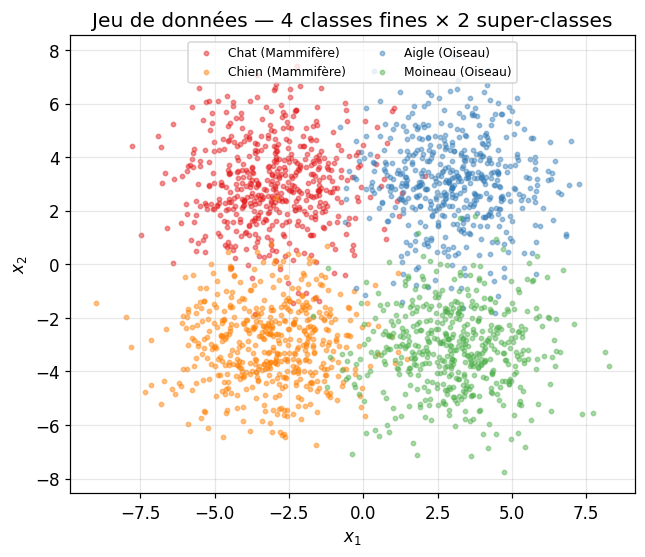

In [21]:
# Visualisation 
names = ["Chat", "Chien", "Aigle", "Moineau"]
colors = ["#e41a1c", "#ff7f00", "#377eb8", "#4daf4a"]
fig, ax = plt.subplots(figsize=(6, 5.2))
for k in range(4):
    m = yf_test == k
    ax.scatter(X_test[m, 0], X_test[m, 1], s=8, c=colors[k], alpha=.45,
               label=f"{names[k]} ({'Mammifère' if k < 2 else 'Oiseau'})")
ax.set_title("Jeu de données — 4 classes fines × 2 super-classes")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(fontsize=8, loc="upper center", ncol=2)
fig.tight_layout(); fig.savefig("figs/data.png", bbox_inches="tight"); plt.show()

## 3. Connecteurs flous différentiables (Łukasiewicz)

Implémentation directe des opérateurs du tableau théorique en PyTorch (donc dérivables).

In [22]:
EPS = 1e-7
def NOT(a):        return 1.0 - a
def AND(a, b):     return torch.clamp(a + b - 1.0, min=0.0)     # t-norme de Łukasiewicz
def OR(a, b):      return torch.clamp(a + b, max=1.0)           # t-conorme
def IMPLIES(a, b): return torch.clamp(1.0 - a + b, max=1.0)     # résidu

def forall(truths, p=4.0):
    # Quantificateur universel par erreur p-moyenne (p>=1 pénalise les faibles vérités)
    return 1.0 - torch.mean((1.0 - truths + EPS) ** p) ** (1.0 / p)

# petit test de cohérence sur les tables de vérité
a = torch.tensor([0.0, 0.0, 1.0, 1.0])
b = torch.tensor([0.0, 1.0, 0.0, 1.0])
print("a->b   :", IMPLIES(a, b).tolist())    # faux uniquement si a=1 et b=0
print("¬(a∧b) :", NOT(AND(a, b)).tolist())   # incompatibilité : faux seulement si a=b=1

a->b   : [1.0, 1.0, 0.0, 1.0]
¬(a∧b) : [1.0, 1.0, 1.0, 0.0]


## 4. Réseau et base de connaissances

Le réseau est un **MLP commun** suivi de **6 têtes sigmoïdes indépendantes**.
`kb_sat` calcule le **degré de satisfaction global** de $\mathcal{K}$ sur un lot de prédictions.

In [23]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU())
        self.head = nn.Linear(64, 6)
    def forward(self, x):
        # 6 sorties sigmoïdes indépendantes (un degré de vérité par prédicat)
        return torch.sigmoid(self.head(self.body(x)))

def axioms(p):
    # satisfaction de chaque axiome, agrégée par le quantificateur ∀ sur le lot
    ax = [
        forall(IMPLIES(p[:, iC], p[:, iM])),   # Chat -> Mammifère
        forall(IMPLIES(p[:, iD], p[:, iM])),   # Chien -> Mammifère
        forall(IMPLIES(p[:, iE], p[:, iB])),   # Aigle -> Oiseau
        forall(IMPLIES(p[:, iS], p[:, iB])),   # Moineau -> Oiseau
        forall(NOT(AND(p[:, iM], p[:, iB]))),  # ¬(Mammifère ∧ Oiseau)
        forall(OR(p[:, iM], p[:, iB])),        # couverture : Mammifère ∨ Oiseau
    ]
    # exclusivité deux à deux des classes fines
    for i in range(4):
        for j in range(i + 1, 4):
            ax.append(forall(NOT(AND(p[:, i], p[:, j]))))
    return torch.stack(ax)

def kb_sat(p):
    return axioms(p).mean()

## 5. Entraînement — perte hybride

La supervision ne porte **que sur les 4 prédicats fins**. Le terme logique s'applique aux
données **non étiquetées** (et donc aussi aux têtes coarse latentes). `λ=0` ⇒ réseau standard.

In [24]:
bce = nn.BCELoss()

def train(lam, epochs=300, lr=0.01):
    torch.manual_seed(SEED)
    net = Net()
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-4)
    hist = []
    for e in range(epochs):
        net.train()
        opt.zero_grad()
        sup = bce(net(Xl)[:, FINE_COLS], T_lab[:, FINE_COLS])               # ancrage supervisé (classes fines)
        logic = (1.0 - kb_sat(net(Xu))) if lam > 0 else torch.tensor(0.0)   # pénalité logique sur le non-étiqueté
        loss = sup + lam * logic
        loss.backward()
        opt.step()
        hist.append((sup.item(), logic.item()))
    return net, hist

net_base, h_base = train(lam=0.0)    # lam=0 : réseau standard, sans contrainte
net_ltn,  h_ltn  = train(lam=5.0)    # LTN avec pénalité logique
print("Entraînement terminé (baseline + LTN).")

Entraînement terminé (baseline + LTN).


## 6. Évaluation — précision **et** cohérence logique

Une prédiction est binarisée au seuil 0,5. On mesure la **précision** (fine et coarse) et le
**taux de violation** de chaque catégorie d'axiomes sur l'ensemble de test.

In [25]:
@torch.no_grad()
def evaluate(net):
    net.eval(); p = net(Xt).numpy(); b = p >= 0.5
    acc_fine   = (p[:, :4].argmax(1) == yf_test).mean()
    true_coarse = np.where(yf_test < 2, 0, 1)            # 0=Mammifère, 1=Oiseau
    acc_coarse = ((p[:, iB] > p[:, iM]).astype(int) == true_coarse).mean()
    v_hier = ((b[:, iC] & ~b[:, iM]) | (b[:, iD] & ~b[:, iM]) |
              (b[:, iE] & ~b[:, iB]) | (b[:, iS] & ~b[:, iB])).mean()
    v_excl = (b[:, iM] & b[:, iB]).mean()
    v_cov  = (~b[:, iM] & ~b[:, iB]).mean()
    v_any  = ((b[:, iC] & ~b[:, iM]) | (b[:, iD] & ~b[:, iM]) | (b[:, iE] & ~b[:, iB]) |
              (b[:, iS] & ~b[:, iB]) | (b[:, iM] & b[:, iB]) | (~b[:, iM] & ~b[:, iB])).mean()
    return dict(acc_fine=acc_fine, acc_coarse=acc_coarse, viol_hier=v_hier,
                viol_excl=v_excl, viol_cov=v_cov, viol_any=v_any, sat=float(kb_sat(net(Xt))))

mb, ml = evaluate(net_base), evaluate(net_ltn)
rows = [("Précision fines",      mb['acc_fine'],   ml['acc_fine']),
        ("Précision super-cl.",  mb['acc_coarse'], ml['acc_coarse']),
        ("Satisfaction K",       mb['sat'],        ml['sat']),
        ("Viol. hiérarchie",     mb['viol_hier'],  ml['viol_hier']),
        ("Viol. exclusivité",    mb['viol_excl'],  ml['viol_excl']),
        ("Viol. couverture",     mb['viol_cov'],   ml['viol_cov']),
        ("Viol. (au moins 1)",   mb['viol_any'],   ml['viol_any'])]
print(f"{'Métrique':<22}{'Standard (λ=0)':>16}{'LTN (λ=5)':>14}")
print("-" * 52)
for name, vb, vl in rows:
    print(f"{name:<22}{vb:>16.3f}{vl:>14.3f}")

Métrique                Standard (λ=0)     LTN (λ=5)
----------------------------------------------------
Précision fines                  0.934         0.938
Précision super-cl.              0.836         0.967
Satisfaction K                   0.880         0.999
Viol. hiérarchie                 0.009         0.000
Viol. exclusivité                0.854         0.000
Viol. couverture                 0.000         0.000
Viol. (au moins 1)               0.863         0.000


**Lecture des résultats.** Le réseau standard atteint une bonne précision sur les classes
fines (qu'il voit, 0,934). Sur les super-classes il obtient encore 0,836 : la métrique compare
seulement quelle tête coarse est la plus active (`Mammifère` vs `Oiseau`), un argmax binaire qui
reste informatif même sans supervision. Son vrai défaut est logique : il viole l'exclusivité
dans 85 % des cas (têtes `Mammifère` et `Oiseau` actives en même temps) et viole au moins un
axiome sur 86 % des exemples. Le LTN garde la même précision fine, fait monter la précision
coarse à ~97 % et surtout annule les violations : il a appris des super-classes cohérentes
uniquement par la logique.

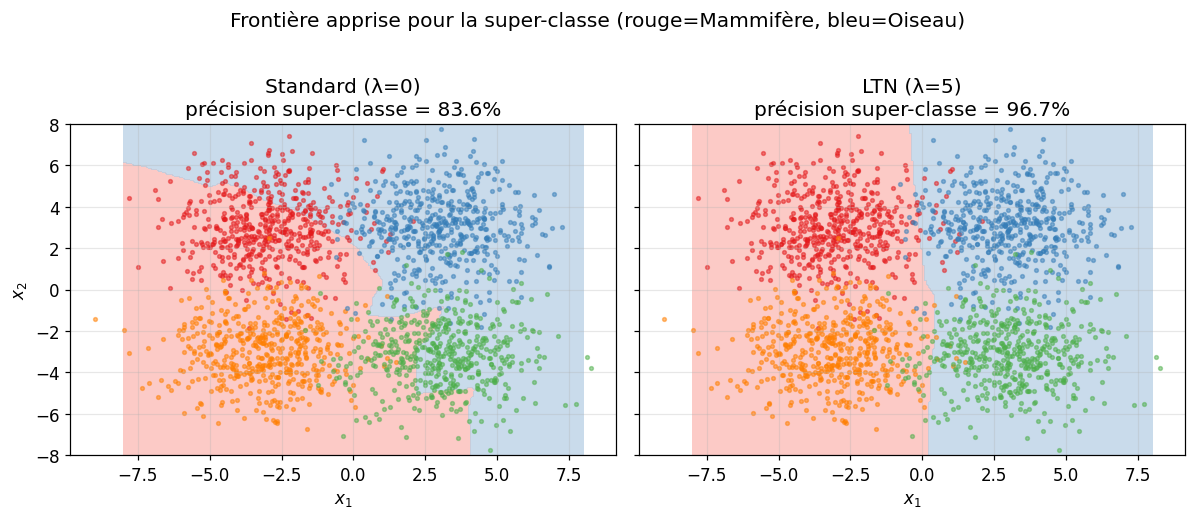

In [26]:
# Régions de décision pour la super-classe Oiseau vs Mammifère
xx, yy = np.meshgrid(np.linspace(-8, 8, 220), np.linspace(-8, 8, 220))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, net, ttl in [(axes[0], net_base, "Standard (λ=0)"), (axes[1], net_ltn, "LTN (λ=5)")]:
    with torch.no_grad():
        pg = net(grid).numpy()
    region = (pg[:, iB] > pg[:, iM]).reshape(xx.shape)   # bleu=Oiseau, rouge=Mammifère
    ax.contourf(xx, yy, region, levels=1, colors=["#fbb4ae", "#b3cde3"], alpha=.7)
    for k in range(4):
        m = yf_test == k
        ax.scatter(X_test[m, 0], X_test[m, 1], s=6, c=colors[k], alpha=.5)
    ax.set_title(f"{ttl}\nprécision super-classe = {evaluate(net)['acc_coarse']:.1%}")
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.suptitle("Frontière apprise pour la super-classe (rouge=Mammifère, bleu=Oiseau)", y=1.02)
fig.tight_layout(); fig.savefig("figs/regions.png", bbox_inches="tight"); plt.show()

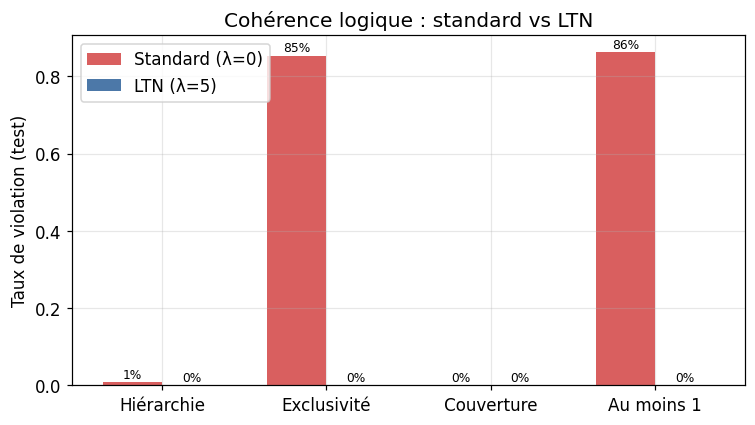

In [19]:
# Comparaison des taux de violation par type d'axiome
cats = ["Hiérarchie", "Exclusivité", "Couverture", "Au moins 1"]
vb = [mb['viol_hier'], mb['viol_excl'], mb['viol_cov'], mb['viol_any']]
vl = [ml['viol_hier'], ml['viol_excl'], ml['viol_cov'], ml['viol_any']]
x = np.arange(len(cats)); w = 0.36
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, vb, w, label="Standard (λ=0)", color="#d95f5f")
ax.bar(x + w/2, vl, w, label="LTN (λ=5)",      color="#4c78a8")
ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_ylabel("Taux de violation (test)")
ax.set_title("Cohérence logique : standard vs LTN"); ax.legend()
for i, (a, b) in enumerate(zip(vb, vl)):
    ax.text(i - w/2, a + .01, f"{a:.0%}", ha="center", fontsize=8)
    ax.text(i + w/2, b + .01, f"{b:.0%}", ha="center", fontsize=8)
fig.tight_layout(); fig.savefig("figs/violations.png", bbox_inches="tight"); plt.show()

## 7. Compromis précision ↔ cohérence (balayage de λ)

On fait varier le poids logique $\lambda$ pour observer son effet sur la précision et les violations.

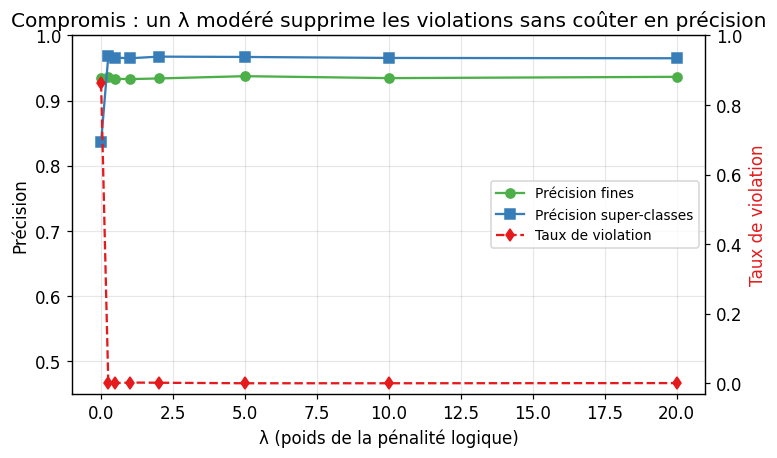

     λ  acc_fine  acc_coarse  viol_any   sat_K
  0.00     0.934       0.836     0.863   0.880
  0.25     0.935       0.968     0.002   0.995
  0.50     0.933       0.966     0.001   0.998
  1.00     0.933       0.965     0.002   0.998
  2.00     0.934       0.968     0.002   0.999
  5.00     0.938       0.967     0.000   0.999
 10.00     0.934       0.966     0.000   1.000
 20.00     0.936       0.965     0.001   0.999


In [20]:
lams = [0.0, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
res = [evaluate(train(lam=l)[0]) for l in lams]
acc_f = [r['acc_fine'] for r in res]; acc_c = [r['acc_coarse'] for r in res]
viol  = [r['viol_any'] for r in res]; sat = [r['sat'] for r in res]

fig, ax1 = plt.subplots(figsize=(7.2, 4.3))
ax1.plot(lams, acc_f, "o-", color="#4daf4a", label="Précision fines")
ax1.plot(lams, acc_c, "s-", color="#377eb8", label="Précision super-classes")
ax1.set_xlabel("λ (poids de la pénalité logique)"); ax1.set_ylabel("Précision")
ax1.set_ylim(0.45, 1.0)
ax2 = ax1.twinx()
ax2.plot(lams, viol, "d--", color="#e41a1c", label="Taux de violation")
ax2.set_ylabel("Taux de violation", color="#e41a1c"); ax2.set_ylim(-0.03, 1.0)
ax2.grid(False)
l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="center right", fontsize=9)
ax1.set_title("Compromis : un λ modéré supprime les violations sans coûter en précision")
fig.tight_layout(); fig.savefig("figs/tradeoff.png", bbox_inches="tight"); plt.show()

print(f"{'λ':>6}{'acc_fine':>10}{'acc_coarse':>12}{'viol_any':>10}{'sat_K':>8}")
for l, r in zip(lams, res):
    print(f"{l:>6.2f}{r['acc_fine']:>10.3f}{r['acc_coarse']:>12.3f}{r['viol_any']:>10.3f}{r['sat']:>8.3f}")

## 8. Conclusion

- Implémentation LTN complète et autonome : connecteurs de Łukasiewicz et quantificateur ∀ par
  erreur p-moyenne, différentiables et entraînés de bout en bout en PyTorch.
- La logique remplace l'étiquetage : les super-classes, jamais supervisées, gagnent en précision
  (0,836 → ~97 %) et deviennent surtout logiquement cohérentes par simple propagation des
  axiomes, là où le réseau standard les prédit de façon contradictoire.
- Cohérence quasi gratuite : le taux de violation chute de ~86 % à 0 % (l'exclusivité
  `¬(Mammifère ∧ Oiseau)`, violée à 85 % par le réseau standard, est entièrement respectée)
  tandis que la précision sur les classes fines est préservée, voire légèrement améliorée (effet
  régularisant de la semi-supervision logique).
- Compromis maîtrisé : un λ modéré (≈1–5) suffit ; au-delà la précision reste stable. Il n'y a
  pas ici de tension forte entre précision et cohérence, la logique jouant le rôle d'a priori
  structurel.

### Limites et pistes
Sémantique de Łukasiewicz (gradients constants ou nuls hors de la zone active) face au produit ;
passage à des données réelles hiérarchiques (super-classes CIFAR-100) ; ajout du quantificateur ∃
et de règles plus riches ; comparaison avec les LNN d'IBM (bornes de vérité, inférence
bidirectionnelle).

### Références
- Badreddine et al. (2022). Logic Tensor Networks. Artificial Intelligence.
- Riegel et al. (2020). Logical Neural Networks. arXiv:2006.13155.
- Garcez & Lamb (2024). Neurosymbolic AI: The 3rd Wave.